In [ ]:
##this script is used for extracting the ms2 data from the targetd msms data and used for spectrum comparison.
##this script is used for compiling standard spectra from data acquired from chemical standards.
##install pyopenms
# !pip install pyopenms
# !pip install numpy
# !pip install tabulate
# !pip install matchms

Number of MS2 scans: 3871
MS2 retention time range: 2.98999999998 - 1199.865 seconds


C:\Users\yangj\AppData\Local\Temp\ipykernel_19632\812304076.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


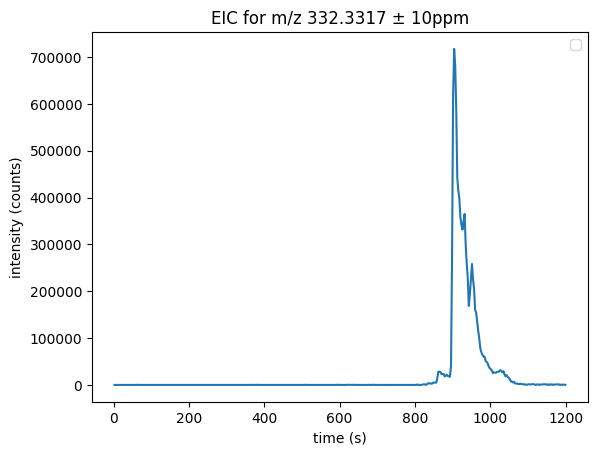

Number of MS2 scans: 3871
MS2 retention time range: 2.98999999998 - 1199.865 seconds


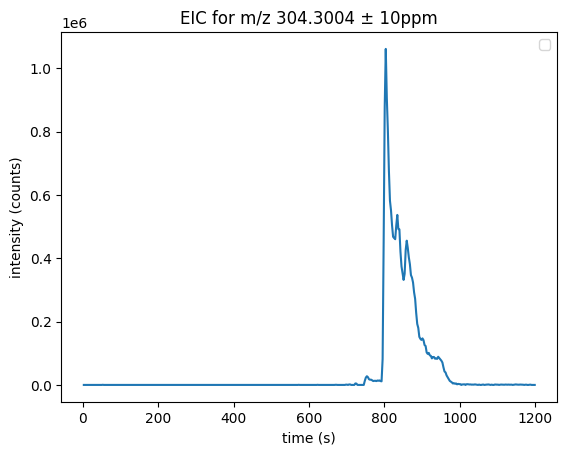

Number of MS2 scans: 3870
MS2 retention time range: 3.06700000002 - 1199.40400000002 seconds


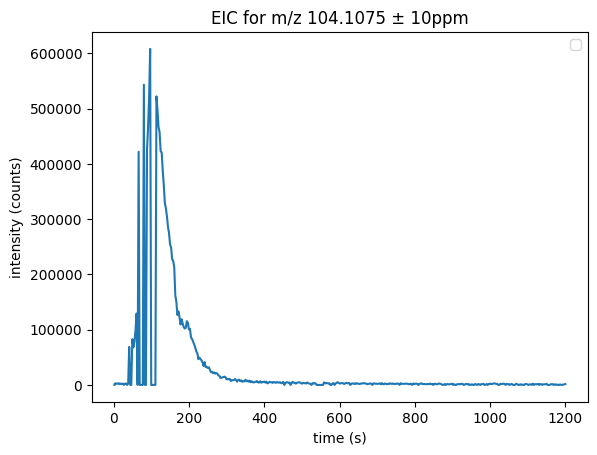

Number of MS2 scans: 3693
MS2 retention time range: 2.95000000002 - 1199.52400000002 seconds


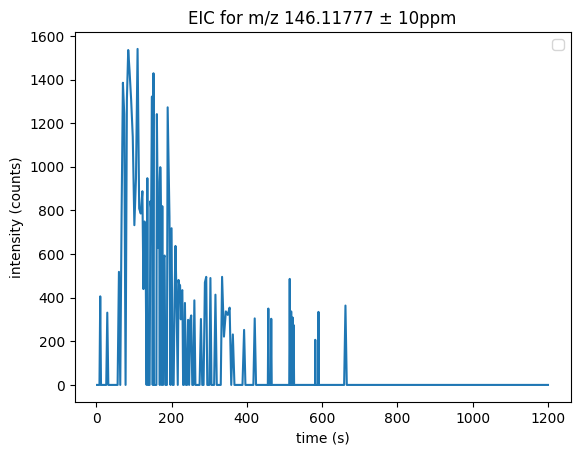

Number of MS2 scans: 3695
MS2 retention time range: 2.79199999998 - 1199.80399999998 seconds


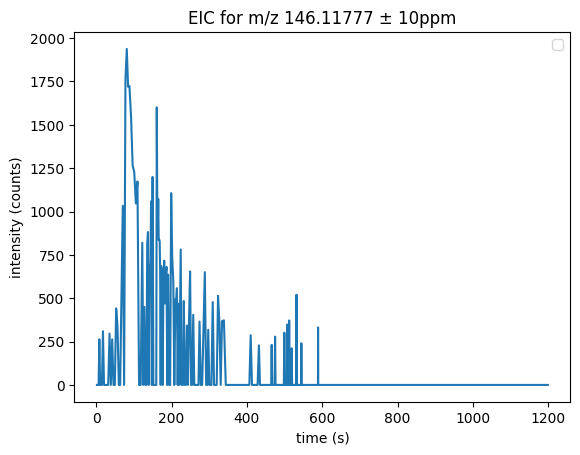

Number of MS2 scans: 3693
MS2 retention time range: 2.95000000002 - 1199.52400000002 seconds


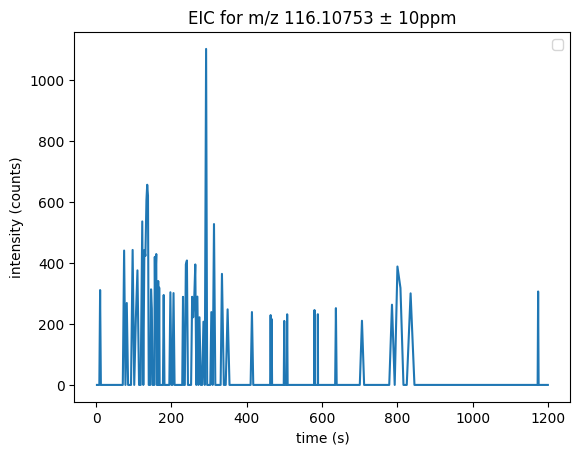

Number of MS2 scans: 0
Error processing MS2 scans: min() arg is an empty sequence


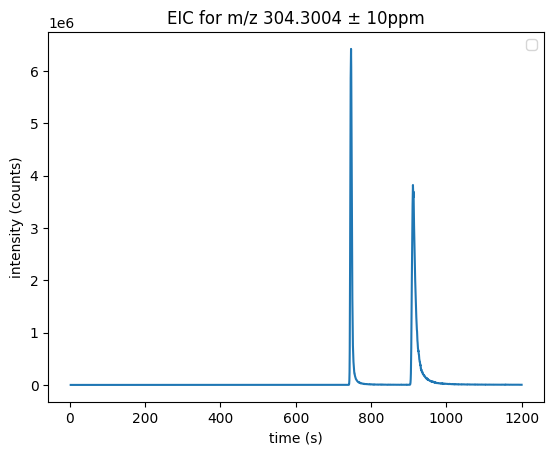

In [ ]:
#function area
import pyopenms as oms
import numpy as np
import matplotlib.pyplot as plt

#function to plot EIC according to target mz and mz tolerance in ppm
def eic_plotter(mzml_file, target_mz, mz_tol=10):
    exp = oms.MSExperiment()
    oms.MzMLFile().load(mzml_file, exp)
    
    retention_times = []
    intensities = []
    
    #get mass traces 
    for spec in exp:
        if spec.getMSLevel() == 1:
            rt = spec.getRT()
            mzs, ints = spec.get_peaks()
            #filter mzs within the tolerance
            filtered_ints = [ints[i] for i in range(len(mzs)) if abs(mzs[i] - target_mz)/target_mz*1e6 <= mz_tol]
            total_intensity = sum(filtered_ints)
            retention_times.append(rt)
            intensities.append(total_intensity)
    
    #get the RT and intensity arrays of the MS2 scans
    ms2_retention_times = []
    ms2_intensities = []
    try:
        for spec in exp:
            if spec.getMSLevel() == 2:
                ms2_retention_times.append(spec.getRT())
                ms2_intensities.append(sum(spec.get_peaks()[1]))
            #print the number of ms2 scans
        print(f"Number of MS2 scans: {len(ms2_retention_times)}")
        #print the range of ms2_retention_times
        print(f"MS2 retention time range: {min(ms2_retention_times)} - {max(ms2_retention_times)} seconds")
    except Exception as e:
        print(f"Error processing MS2 scans: {e}")

    #plot the EIC
    plt.plot(retention_times, intensities)
    plt.title(f"EIC for m/z {target_mz} ± {mz_tol}ppm")
    plt.xlabel("time (s)")
    plt.ylabel("intensity (counts)")
    # plot the ms2 scan points
    # if len(ms2_retention_times) > 0:
    #     plt.scatter(ms2_retention_times, ms2_intensities, color='red', label='MS2 scans', 
    #                 #make a small size for the points
    #                 s=1)
    # else:
    #     print("No MS2 scans found.")
    plt.legend()
    plt.show()

#plot eic based on target mz and target rt
filepath1 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04549 _aMSMS_pos.mzML'
filepath2 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04549 _aMSMS_pos.mzML'
filepath3 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04385 _aMSMS_pos.mzML'
filepath4 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\samples_automsms_positive\Pool_sample_for_QACs_pos_150FV.mzML'
filepath5 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\samples_automsms_positive\Pool_sample_for_QACs_pos.mzML'
filepath6 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\samples_automsms_positive\Pool_sample_for_QACs_pos_150FV.mzML'
filepath7 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\03102026\03102026\CAL4_r1.mzML'

mz1 = 332.3317
mz2 = 304.3004 #C12-BAC
mz3 = 104.1075
mz4 = 146.11777
mz5 = 146.11777
mz6 = 116.10753


#automsms
eic_plotter(filepath1, target_mz=mz1, mz_tol=10)
eic_plotter(filepath2, target_mz=mz2, mz_tol=10)
eic_plotter(filepath3, target_mz=mz3, mz_tol=10)
eic_plotter(filepath4, target_mz=mz4, mz_tol=10)
eic_plotter(filepath5, target_mz=mz5, mz_tol=10)
eic_plotter(filepath6, target_mz=mz6, mz_tol=10)

#eic from mixtures of 13 standards
eic_plotter(filepath7, target_mz=mz2, mz_tol=10)


In [ ]:
#eic generator function 2 : extract intensity between a specified rt range and target mz with tolerance, yet plot the chromatogram of the entire original rt range.
import pyopenms as oms
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

def eic_plotter_rt_range(mzml_file, target_mz, target_rt, mz_tol=10, rt_tol=2, apply_smoothing=True, window_length=11, polyorder=3, normalize=True, fill_color='blue', fill_alpha=0.2):
    exp = oms.MSExperiment()
    oms.MzMLFile().load(mzml_file, exp)
    
    retention_times = []
    intensities = []
    
    # Pre-calculate static bounds outside the loop
    rtmin = (target_rt - rt_tol) * 60
    rtmax = (target_rt + rt_tol) * 60
    
    mz_margin = target_mz * (mz_tol / 1e6)
    min_mz = target_mz - mz_margin
    max_mz = target_mz + mz_margin
    
    print(f"RT range for EIC extraction: {rtmin/60:.2f} - {rtmax/60:.2f} minutes")
    print(f"Extraction m/z window: {min_mz:.4f} - {max_mz:.4f} Da")
    
    # Extract mass traces 
    for spec in exp:
        if spec.getMSLevel() == 1:
            rt = spec.getRT()
            
            if rtmin <= rt <= rtmax:
                mzs, ints = spec.get_peaks() 
                mask = (mzs >= min_mz) & (mzs <= max_mz)
                total_intensity = np.sum(ints[mask])
            else:
                total_intensity = 0.0
                
            retention_times.append(rt)
            intensities.append(total_intensity)
    
    retention_times = np.array(retention_times) / 60.0
    intensities = np.array(intensities)
    
    # --- NEW: Normalization Logic ---
    if normalize and len(intensities) > 0:
        max_int = np.max(intensities)
        if max_int > 0:
            intensities = (intensities / max_int) * 100.0
            y_label = "Relative Intensity (%)"
        else:
            y_label = "Intensity (counts)" # Fallback if perfectly empty
    else:
        y_label = "Intensity (counts)"
    
    # Apply Savitzky-Golay smoothing on the (potentially normalized) data
    if apply_smoothing and len(intensities) > window_length:
        if window_length % 2 == 0:
            window_length += 1
            
        intensities_smoothed = savgol_filter(intensities, window_length=window_length, polyorder=polyorder)
        intensities_smoothed = np.clip(intensities_smoothed, 0, None)
    else:
        intensities_smoothed = intensities

    max_idx = np.argmax(intensities_smoothed)
    max_rt = retention_times[max_idx]

    # Plot the EIC
    plt.figure(figsize=(10, 4))
    
    if apply_smoothing:
        # plt.plot(retention_times, intensities, color='lightgray', label="Raw Data", linewidth=0.5)
        # plt.plot(retention_times, intensities_smoothed, color=fill_color, label="Savitzky-Golay Smoothed", linewidth=0.5)
        plt.plot(retention_times, intensities_smoothed, color=fill_color,linewidth=0.5)
        plt.fill_between(retention_times, intensities_smoothed, color=fill_color, alpha=fill_alpha)
    else:
        plt.plot(retention_times, intensities, color=fill_color, label="Raw Data", linewidth=0.5)
        plt.fill_between(retention_times, intensities, color=fill_color, alpha=fill_alpha)

    plt.title(f"EIC for m/z {target_mz} ± {mz_tol}ppm (RT: {max_rt:.2f} min)")
    plt.xlabel("Time (min)", fontweight='bold')
    # Dynamically update the Y-axis label based on normalization
    plt.ylabel(y_label, fontweight='bold') 
    plt.legend()
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Optional: Force the Y-axis to start exactly at 0 to prevent floating baselines
    plt.ylim(bottom=0) 
    
    plt.show()

# filepath7 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\03102026\03102026\CAL6_r1.mzML'

# mz2 = 304.3004 #C12-BAC
# mz3 = 104.1075
# mz4 = 146.11777

# eic_plotter_rt_range(filepath7, target_mz=mz2, mz_tol=10, target_rt=12.46, rt_tol=0.5,apply_smoothing=True)

RT range for EIC extraction: 0.58 - 0.98 minutes
Extraction m/z window: 104.1065 - 104.1085 Da


C:\Users\yangj\AppData\Local\Temp\ipykernel_17236\934288383.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


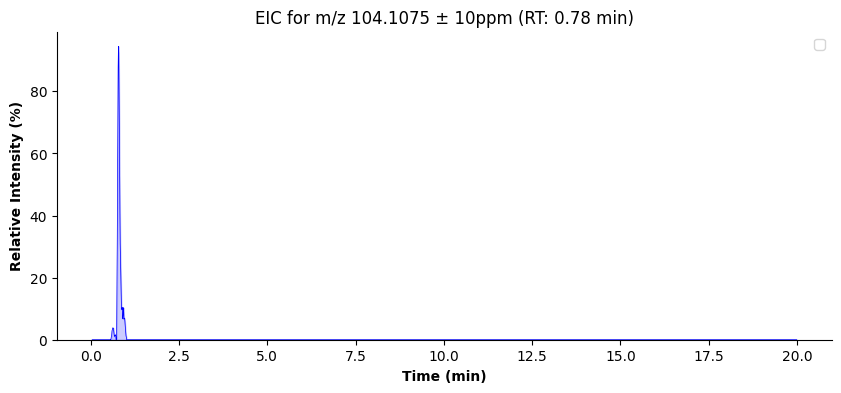

In [46]:
eic_plotter_rt_range(filepath7, target_mz=mz3, mz_tol=10, target_rt=0.783, rt_tol=0.2)

RT range for EIC extraction: 0.57 - 0.97 minutes
Extraction m/z window: 146.1163 - 146.1192 Da


C:\Users\yangj\AppData\Local\Temp\ipykernel_17236\934288383.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


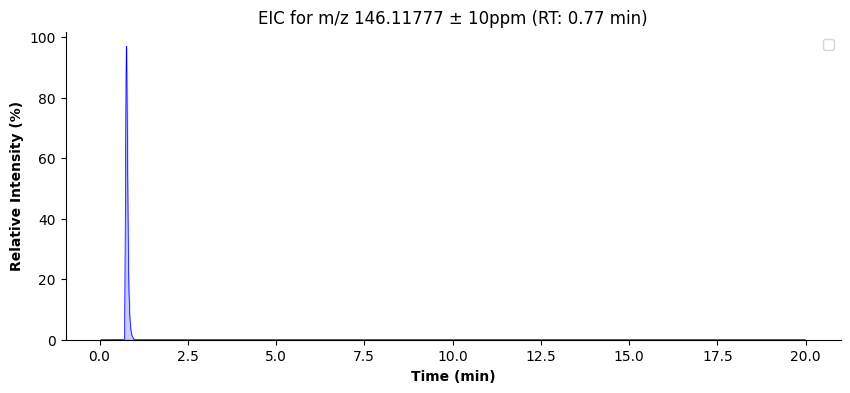

In [47]:
eic_plotter_rt_range(filepath7, target_mz=mz4, mz_tol=10, target_rt=0.766, rt_tol=0.2)

RT range for EIC extraction: 12.50 - 16.50 minutes
Extraction m/z window: 332.3284 - 332.3350 Da


C:\Users\yangj\AppData\Local\Temp\ipykernel_17744\2293899711.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


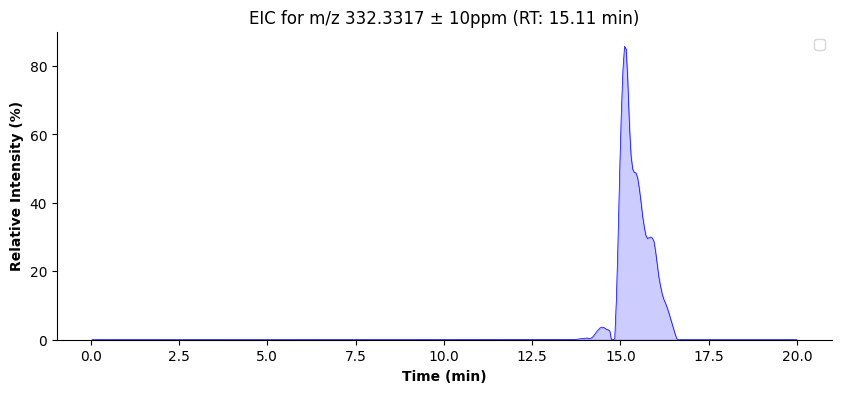

RT range for EIC extraction: 10.45 - 14.45 minutes
Extraction m/z window: 304.2974 - 304.3034 Da


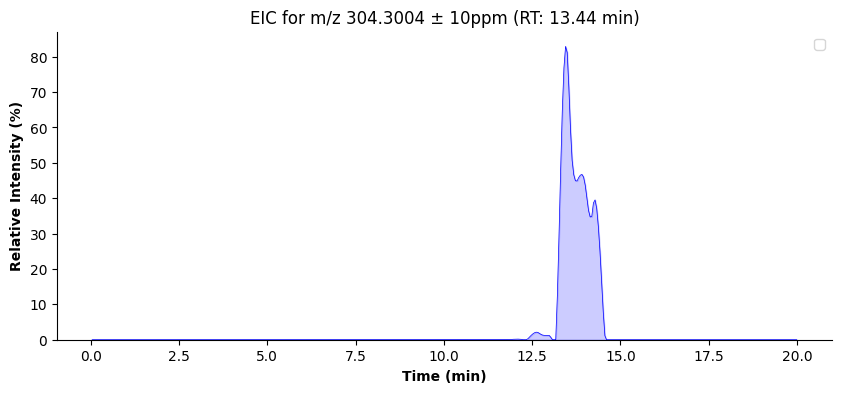

RT range for EIC extraction: -1.22 - 2.78 minutes
Extraction m/z window: 104.1065 - 104.1085 Da


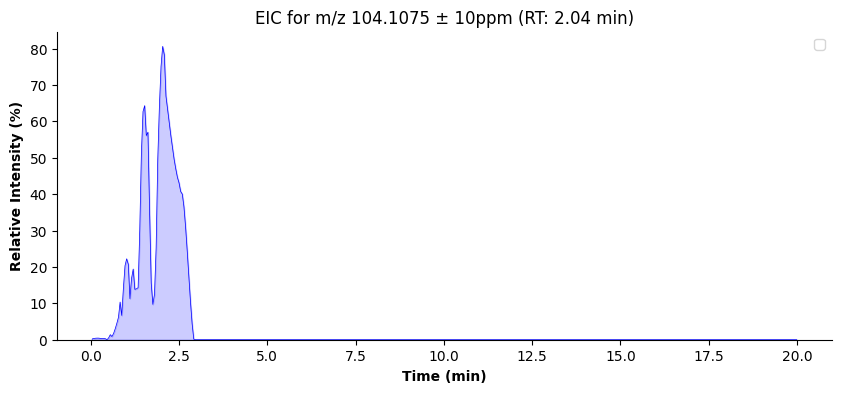

RT range for EIC extraction: -1.23 - 2.77 minutes
Extraction m/z window: 146.1163 - 146.1192 Da


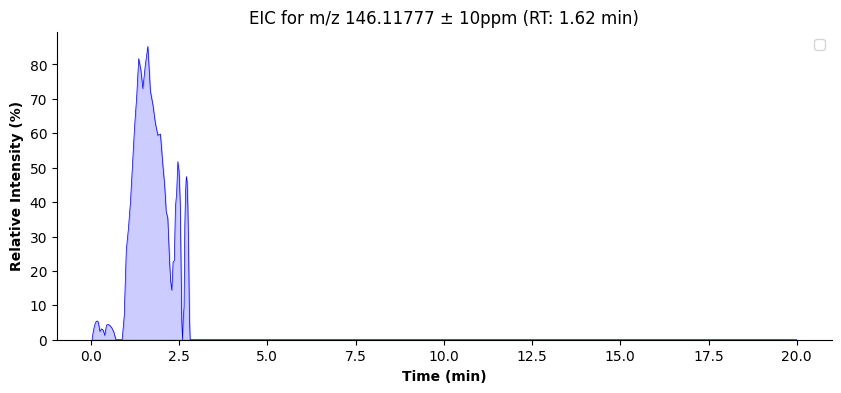

RT range for EIC extraction: 14.22 - 18.22 minutes
Extraction m/z window: 388.3904 - 388.3982 Da


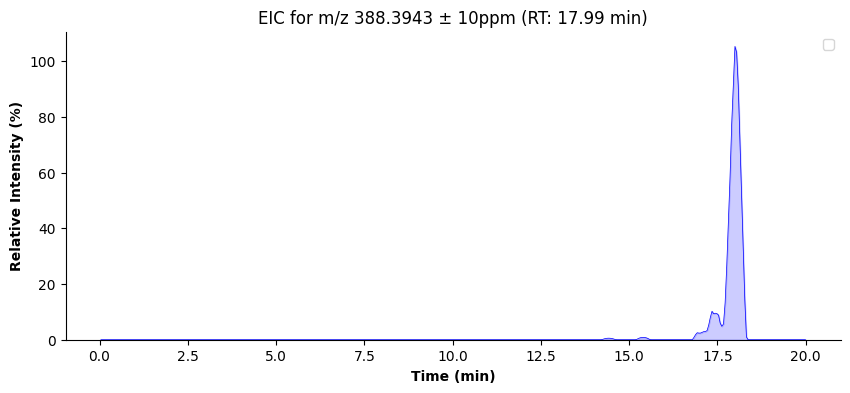

RT range for EIC extraction: 9.21 - 13.21 minutes
Extraction m/z window: 228.2668 - 228.2714 Da


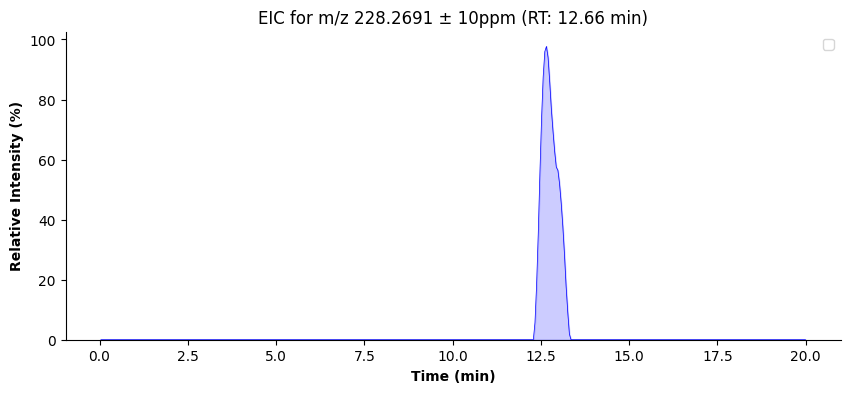

RT range for EIC extraction: 13.51 - 17.51 minutes
Extraction m/z window: 360.3594 - 360.3666 Da


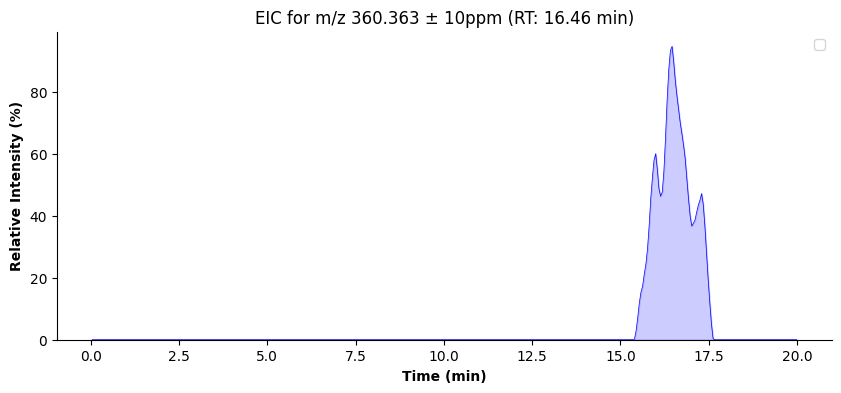

RT range for EIC extraction: 12.99 - 16.99 minutes
Extraction m/z window: 284.3289 - 284.3345 Da


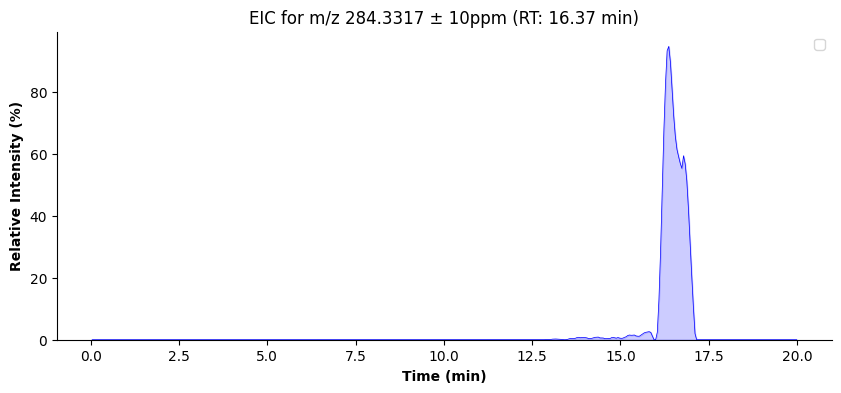

In [ ]:
#eic generator function 2 : extract intensity between a specified rt range and target mz with tolerance, yet plot the chromatogram of the entire original rt range.
import pyopenms as oms
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

def eic_plotter_rt_range(mzml_file, target_mz, target_rt, mz_tol=10, rt_tol=2, apply_smoothing=True, window_length=11, polyorder=3, normalize=True, fill_color='blue', fill_alpha=0.2):
    exp = oms.MSExperiment()
    oms.MzMLFile().load(mzml_file, exp)
    
    retention_times = []
    intensities = []
    
    # Pre-calculate static bounds outside the loop
    rtmin = (target_rt - rt_tol) * 60
    rtmax = (target_rt + rt_tol) * 60
    
    mz_margin = target_mz * (mz_tol / 1e6)
    min_mz = target_mz - mz_margin
    max_mz = target_mz + mz_margin
    
    print(f"RT range for EIC extraction: {rtmin/60:.2f} - {rtmax/60:.2f} minutes")
    print(f"Extraction m/z window: {min_mz:.4f} - {max_mz:.4f} Da")
    
    # Extract mass traces 
    for spec in exp:
        if spec.getMSLevel() == 1:
            rt = spec.getRT()
            
            if rtmin <= rt <= rtmax:
                mzs, ints = spec.get_peaks() 
                mask = (mzs >= min_mz) & (mzs <= max_mz)
                total_intensity = np.sum(ints[mask])
            else:
                total_intensity = 0.0
                
            retention_times.append(rt)
            intensities.append(total_intensity)
    
    retention_times = np.array(retention_times) / 60.0
    intensities = np.array(intensities)
    
    # --- NEW: Normalization Logic ---
    if normalize and len(intensities) > 0:
        max_int = np.max(intensities)
        if max_int > 0:
            intensities = (intensities / max_int) * 100.0
            y_label = "Relative Intensity (%)"
        else:
            y_label = "Intensity (counts)" # Fallback if perfectly empty
    else:
        y_label = "Intensity (counts)"
    
    # Apply Savitzky-Golay smoothing on the (potentially normalized) data
    if apply_smoothing and len(intensities) > window_length:
        if window_length % 2 == 0:
            window_length += 1
            
        intensities_smoothed = savgol_filter(intensities, window_length=window_length, polyorder=polyorder)
        intensities_smoothed = np.clip(intensities_smoothed, 0, None)
    else:
        intensities_smoothed = intensities

    max_idx = np.argmax(intensities_smoothed)
    max_rt = retention_times[max_idx]

    # Plot the EIC
    plt.figure(figsize=(10, 4))
    
    if apply_smoothing:
        # plt.plot(retention_times, intensities, color='lightgray', label="Raw Data", linewidth=0.5)
        # plt.plot(retention_times, intensities_smoothed, color=fill_color, label="Savitzky-Golay Smoothed", linewidth=0.5)
        plt.plot(retention_times, intensities_smoothed, color=fill_color,linewidth=0.5)
        plt.fill_between(retention_times, intensities_smoothed, color=fill_color, alpha=fill_alpha)
    else:
        plt.plot(retention_times, intensities, color=fill_color, label="Raw Data", linewidth=0.5)
        plt.fill_between(retention_times, intensities, color=fill_color, alpha=fill_alpha)

    plt.title(f"EIC for m/z {target_mz} ± {mz_tol}ppm (RT: {max_rt:.2f} min)")
    plt.xlabel("Time (min)", fontweight='bold')
    # Dynamically update the Y-axis label based on normalization
    plt.ylabel(y_label, fontweight='bold') 
    plt.legend()
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Optional: Force the Y-axis to start exactly at 0 to prevent floating baselines
    plt.ylim(bottom=0) 
    
    plt.show()


#plot eic based on target mz and target rt
filepath1 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04549 _aMSMS_pos.mzML'
filepath3 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04385 _aMSMS_pos.mzML'
filepath4 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\samples_automsms_positive\Pool_sample_for_QACs_pos_150FV.mzML'
filepath5 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\samples_automsms_positive\Pool_sample_for_QACs_pos.mzML'
filepath6 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\samples_automsms_positive\Pool_sample_for_QACs_pos_150FV.mzML'
filepath7 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\03102026\03102026\CAL4_r1.mzML'
filepath8 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04297 _aMSMS_pos.mzML'
filepath9 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04362 _aMSMS_pos.mzML'
filepath10 = r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04645 _aMSMS_pos.mzML"

mz1 = 332.3317 #
rt1 = 14.5
mz2 = 304.3004 #C12-BAC
rt2 = 12.446
mz3 = 104.1075 #choline chloride
rt3 = 0.783
mz4 = 146.11777 #(3-carbo)
rt4 = 0.766
mz5 = 388.3943
rt5 = 16.219
# mz6 = 116.10753
# rt6 = 1.0
mz7 = 360.3630 #C16-BAC
rt7 = 15.505
mz8 = 284.3317# C16-ATMC
rt8 = 14.99
mz9 = 228.2691 #C12-ATMMC
rt9 = 11.206


#automsms
eic_plotter_rt_range(filepath1, target_mz=mz1, target_rt=rt1, mz_tol=10)
eic_plotter_rt_range(filepath1, target_mz=mz2, target_rt=rt2, mz_tol=10)
eic_plotter_rt_range(filepath3, target_mz=mz3, target_rt=rt3, mz_tol=10)
eic_plotter_rt_range(filepath4, target_mz=mz4, target_rt=rt4, mz_tol=10)
eic_plotter_rt_range(filepath9, target_mz=mz5, target_rt=rt5, mz_tol=10)
eic_plotter_rt_range(filepath8, target_mz=mz9, target_rt=rt9, mz_tol=10)
eic_plotter_rt_range(filepath9, target_mz=mz7, target_rt=rt7, mz_tol=10)
eic_plotter_rt_range(filepath10, target_mz=mz8, target_rt=rt8, mz_tol=10)

Loading D:\UCSF_postdoc_topic\Collaboration\zheng guomao\JY_QA_02032026\BH04549 _aMSMS_pos.mzML...
Loading D:\UCSF_postdoc_topic\Collaboration\zheng guomao\JY_QA_02032026\BH04362 _aMSMS_pos.mzML...
Loading D:\UCSF_postdoc_topic\Collaboration\zheng guomao\JY_QA_02032026\BH04297 _aMSMS_pos.mzML...
Loading D:\UCSF_postdoc_topic\Collaboration\zheng guomao\JY_QA_02032026\BH04645 _aMSMS_pos.mzML...
Loading D:\UCSF_postdoc_topic\Collaboration\zheng guomao\JY_QA_02032026\BH04385 _aMSMS_pos.mzML...
Loading D:\UCSF_postdoc_topic\Collaboration\zheng guomao\samples_automsms_positive\Pool_sample_for_QACs_pos_150FV.mzML...


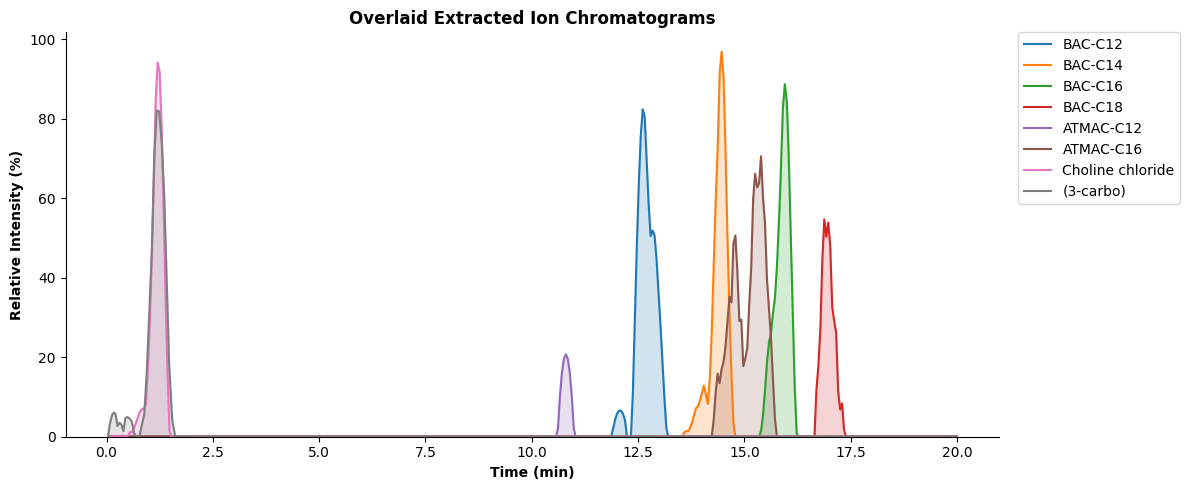

In [ ]:
import pyopenms as oms
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

def plot_stacked_eics(targets, mz_tol=10, rt_tol=1, apply_smoothing=True, window_length=11, polyorder=3, normalize=True, fill_alpha=0.2):
    """
    Extracts and overlays multiple EICs on a single graph.
    targets: A list of dictionaries containing file, mz, rt, and an optional name for the legend.
    """
    # 1. Group targets by file to prevent redundant, slow mzML loading
    files_to_process = {}
    for idx, target in enumerate(targets):
        file_path = target['file']
        if file_path not in files_to_process:
            files_to_process[file_path] = []
        # Store the original index so we can assign colors consistently later
        files_to_process[file_path].append({'idx': idx, **target})

    plot_data = []

    # 2. Process each file exactly once
    for file_path, file_targets in files_to_process.items():
        print(f"Loading {file_path}...")
        exp = oms.MSExperiment()
        try:
            oms.MzMLFile().load(file_path, exp)
        except Exception as e:
            print(f"  [ERROR] Failed to load {file_path}: {e}")
            continue
        
        # 3. Extract all targets associated with this specific file
        for target in file_targets:
            target_mz = target['mz']
            target_rt = target['rt']
            target_name = target.get('name', f"m/z {target_mz:.4f}")
            
            rtmin = (target_rt - rt_tol) * 60
            rtmax = (target_rt + rt_tol) * 60
            mz_margin = target_mz * (mz_tol / 1e6)
            min_mz = target_mz - mz_margin
            max_mz = target_mz + mz_margin
            
            retention_times = []
            intensities = []
            
            for spec in exp:
                if spec.getMSLevel() == 1:
                    rt = spec.getRT()
                    if rtmin <= rt <= rtmax:
                        mzs, ints = spec.get_peaks() 
                        mask = (mzs >= min_mz) & (mzs <= max_mz)
                        total_intensity = np.sum(ints[mask])
                    else:
                        total_intensity = 0.0
                        
                    retention_times.append(rt)
                    intensities.append(total_intensity)
            
            retention_times = np.array(retention_times) / 60.0
            intensities = np.array(intensities)
            
            # Normalization
            if normalize and len(intensities) > 0 and np.max(intensities) > 0:
                intensities = (intensities / np.max(intensities)) * 100.0
            
            # Smoothing
            if apply_smoothing and len(intensities) > window_length:
                wl = window_length if window_length % 2 != 0 else window_length + 1
                intensities_smoothed = savgol_filter(intensities, window_length=wl, polyorder=polyorder)
                intensities_smoothed = np.clip(intensities_smoothed, 0, None)
            else:
                intensities_smoothed = intensities
                
            # Store the final trace
            plot_data.append({
                'idx': target['idx'],
                'rt': retention_times,
                'int': intensities_smoothed,
                'name': target_name
            })
    
    # 4. Plotting Phase
    plt.figure(figsize=(12, 5))
    
    # Sort data back into the original order passed by the user for consistent legend rendering
    plot_data.sort(key=lambda x: x['idx'])
    
    # Use Matplotlib's categorical color palette (tab10 has 10 distinct colors)
    colors = plt.cm.tab10.colors 
    
    for data in plot_data:
        color = colors[data['idx'] % len(colors)]
        plt.plot(data['rt'], data['int'], color=color, linewidth=1.5, label=data['name'])
        plt.fill_between(data['rt'], data['int'], color=color, alpha=fill_alpha)

    # 5. Graph Formatting
    plt.title("Overlaid Extracted Ion Chromatograms", fontweight='bold')
    plt.xlabel("Time (min)", fontweight='bold')
    plt.ylabel("Relative Intensity (%)" if normalize else "Intensity (counts)", fontweight='bold')
    
    # Move the legend outside the graph so it doesn't cover your peaks
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.ylim(bottom=0) 
    
    plt.tight_layout() # Ensures the legend isn't cut off when saving
    plt.show()
    

# --- File Paths ---
filepath1 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04549 _aMSMS_pos.mzML'
filepath3 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04385 _aMSMS_pos.mzML'
filepath4 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\samples_automsms_positive\Pool_sample_for_QACs_pos_150FV.mzML'
filepath8 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04297 _aMSMS_pos.mzML'
filepath9 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04362 _aMSMS_pos.mzML'
filepath10 = r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\JY_QA_02032026\BH04645 _aMSMS_pos.mzML"

# --- Define Targets ---
target_list = [
    {'file': filepath1,  'mz': 304.3004, 'rt': 12.446,  'name': 'BAC-C12'},
    {'file': filepath1,  'mz': 332.3317, 'rt': 14.037,    'name': 'BAC-C14'},
    {'file': filepath9,  'mz': 360.3630, 'rt': 15.505,  'name': 'BAC-C16'},
    {'file': filepath9,  'mz': 388.3943, 'rt': 16.591,  'name': 'BAC-C18'},
    {'file': filepath8,  'mz': 228.2691, 'rt': 11.206,  'name': 'ATMAC-C12'},
    {'file': filepath10, 'mz': 284.3317, 'rt': 15.001,   'name': 'ATMAC-C16'},
    {'file': filepath3,  'mz': 104.1075, 'rt': 0.783,   'name': 'Choline chloride'},
    {'file': filepath4,  'mz': 146.1177, 'rt': 0.766,   'name': '(3-carbo)'},
]

# --- Generate the Overlaid Plot ---
plot_stacked_eics(target_list, mz_tol=15, rt_tol=0.6, normalize=True)

Loading D:\UCSF_postdoc_topic\Collaboration\zheng guomao\Copy of 04022026\CAL6_r1.mzML...


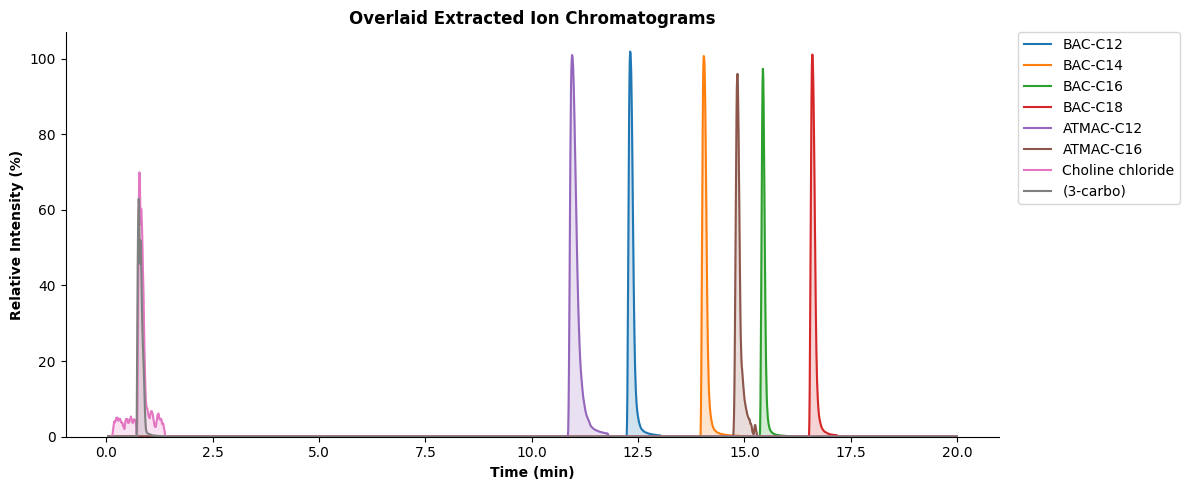

In [ ]:
# eic_plotter_rt_range(filepath7, target_mz=mz7, target_rt=rt7, mz_tol=10)
# --- File Paths ---
# filepath7 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\03102026\03102026\CAL4_r1.mzML'
filepath7 = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\Copy of 04022026\CAL6_r1.mzML'

# --- Define Targets ---
target_list = [
    {'file': filepath7,  'mz': 304.3004, 'rt': 12.446,  'name': 'BAC-C12'},
    {'file': filepath7,  'mz': 332.3317, 'rt': 14.037,    'name': 'BAC-C14'},
    {'file': filepath7,  'mz': 360.3630, 'rt': 15.505,  'name': 'BAC-C16'},
    {'file': filepath7,  'mz': 388.3943, 'rt': 16.591,  'name': 'BAC-C18'},
    {'file': filepath7,  'mz': 228.2691, 'rt': 11.206,  'name': 'ATMAC-C12'},
    {'file': filepath7, 'mz': 284.3317, 'rt': 15.003,   'name': 'ATMAC-C16'},
    {'file': filepath7,  'mz': 104.1075, 'rt': 0.761,   'name': 'Choline chloride'},
    {'file': filepath7,  'mz': 146.1177, 'rt': 0.766,   'name': '(3-carbo)'}
]

# --- Generate the Overlaid Plot ---
plot_stacked_eics(target_list, mz_tol=15, rt_tol=0.6, normalize=True)

In [ ]:
#import ms1 data
from operator import index
import pandas as pd
ms1_filepath = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\mathced_peaks_pos_QACs_withmean_intensity_20260309.csv'
matched_raw_area = pd.read_csv(ms1_filepath)
print(len([col for col in matched_raw_area.columns if col.startswith('BH')]))
#calculate the detection frequency for the compounds
#filter summary dataframe
matched_raw_area['feature_id'] = matched_raw_area['Average Mz'].astype(str) + '_' + matched_raw_area['Average Rt(min)'].astype(str)

#filter columns, retain feature_id and columns starts with BH
# stats_df_DF = matched_raw_area[['feature_id']+[col for col in matched_raw_area.columns if col.startswith('BH')]]

#calculate the detection frequency for the matched peaks = number of sample column with peak area >=5000 / total number of sample column, sample column starts with BH
matched_raw_area['Detection frequency'] = matched_raw_area[[col for col in matched_raw_area.columns if col.startswith('BH')]].apply(lambda x: (x >= 5000).sum() / len(x), axis=1)
# stats_df_DF['Detection frequency'] = stats_df_DF.iloc[:,1:].apply(lambda x: (x >= 5000).sum() / len(x), axis=1)*100

#describe the detection frequency stats
matched_raw_area['Detection frequency'].describe()


400


count    231.000000
mean       0.351699
std        0.295231
min        0.000000
25%        0.068750
50%        0.340000
75%        0.556250
max        1.000000
Name: Detection frequency, dtype: float64

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Load the database ---
QA_database_path = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QACs_chemical_list_comptox_March09.csv'
peakmzrt = pd.read_csv(QA_database_path)

# --- 2. Merge RT to the stats_df_DF ---
stats_df_DF = pd.merge(matched_raw_area, peakmzrt, how='left', on='DTXSID')

# --- 3. Calculate Detection Frequency ---
sample_cols = [col for col in stats_df_DF.columns if str(col).startswith('BH')]
stats_df_DF['Detection_Freq'] = (stats_df_DF[sample_cols] > 0).sum(axis=1)

selected_rows_df = pd.DataFrame()

# --- 4. Process rows with valid RT2 (or RT1) and screen ---
if 'RT2' in stats_df_DF.columns and 'RT1' in stats_df_DF.columns:
    
    cond_rt2 = stats_df_DF['RT2'].notna() & (abs(stats_df_DF['Average Rt(min)'] - stats_df_DF['RT2']) <= 0.5)
    cond_rt1 = stats_df_DF['RT2'].isna() & stats_df_DF['RT1'].notna() & (abs(stats_df_DF['Average Rt(min)'] - stats_df_DF['RT1']) <= 2.0)
    
    rt_valid_mask = cond_rt2 | cond_rt1
    filtered_df = stats_df_DF[rt_valid_mask]
    
    # --- 5. Group by DTXSID and retain row with highest detection frequency ---
    selected_rows_df = (filtered_df
                        .sort_values(by=['DTXSID', 'Detection_Freq'], ascending=[True, False])
                        .drop_duplicates(subset=['DTXSID'], keep='first')
                        .reset_index(drop=True))
                        
    # --- 6. Reorder rows to put target DTXSIDs at the top ---
    top_target = [
        'DTXSID4020325', # Added from your comment
        'DTXSID00978073',
        "DTXSID6026901",
        "DTXSID1026900",
        'DTXSID2040787',
        "DTXSID3041665",
        'DTXSID4046606',
        'DTXSID1044643',
        "DTXSID9035549",
        "DTXSID2025139" 
    ]
    
    # Create a temporary boolean column: True if the DTXSID is in the top_target list
    selected_rows_df['is_priority'] = selected_rows_df['DTXSID'].isin(top_target)
    
    # Sort by the priority flag (True/1 comes before False/0 when descending)
    # Secondary sort by Detection_Freq keeps the rest of the dataframe organized logically
    selected_rows_df = (selected_rows_df
                        .sort_values(by=['is_priority', 'Detection_Freq'], ascending=[False, False])
                        .drop(columns=['is_priority']) # Clean up the helper column
                        .reset_index(drop=True))

else:
    print("Warning: 'RT1' or 'RT2' columns not found in the merged dataframe. Check your QA_database columns.")
    


In [23]:
#
import tabulate
print(selected_rows_df.shape)
print(tabulate.tabulate(selected_rows_df,headers='keys', tablefmt='psql'))

(26, 428)
+----+--------------+-------------------+--------------+---------------------------------------------------------------------+-----------------------------+----------------+-------------------+------------------------------+--------------+---------------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------------------+-----------------+-----------+------------------+-----------------+------------------+-----------+-----------+-----------+-----------+-----------+-----------+------------------+-----------------+---------------

In [ ]:
#output selected_rows_df
selected_rows_df.to_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_matched_detectionfrequency.csv")

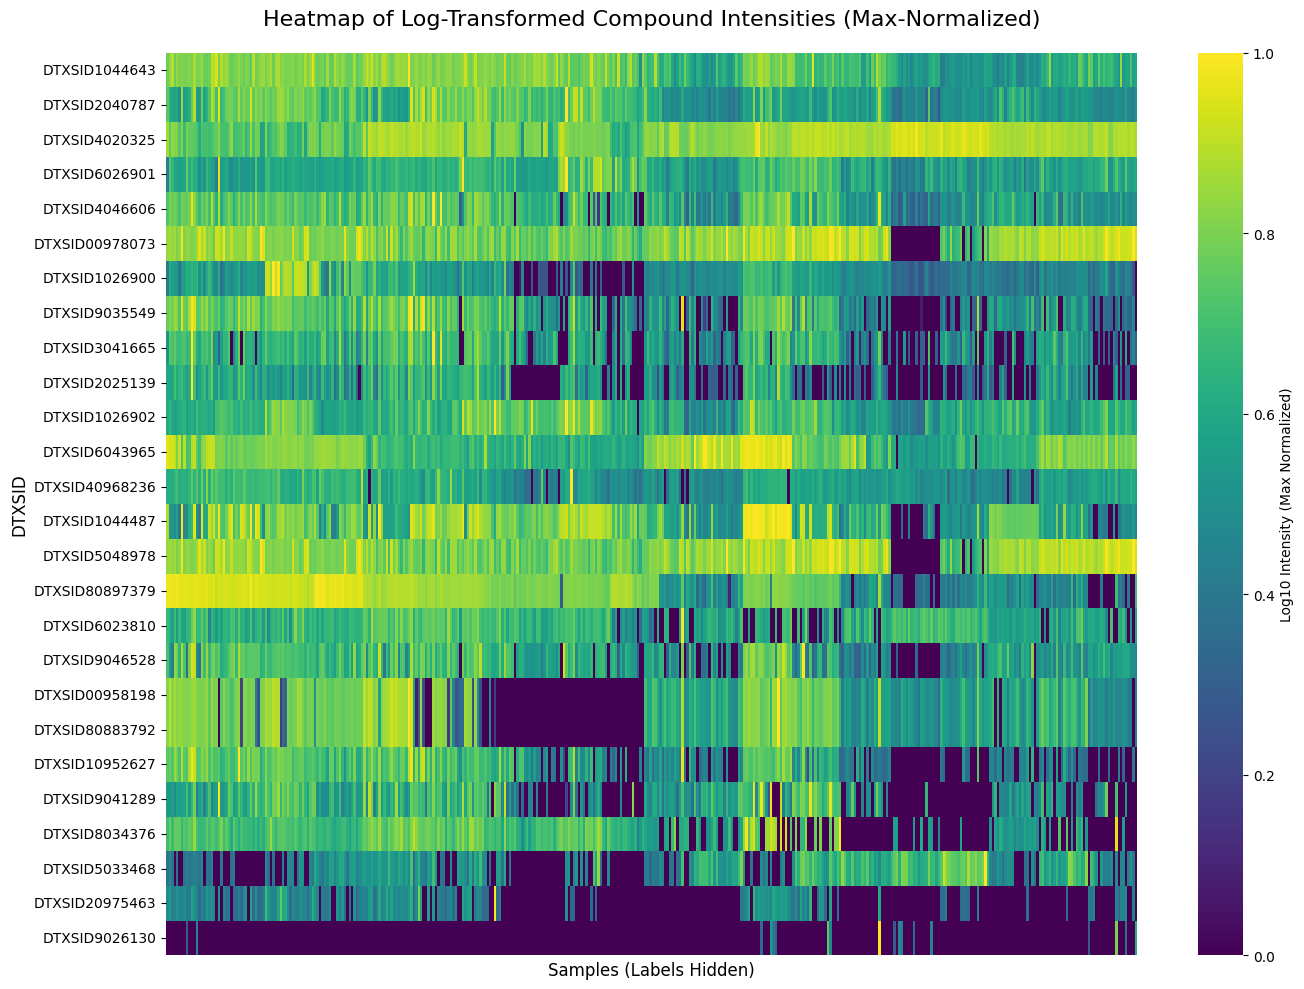

In [5]:
#make heatmap plot for the dataset, using column values starts with BH, might need to do normalization across each row, 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Assuming 'selected_rows_df' is the final dataframe from the previous steps ---

# 1. Isolate the target columns ('BH' samples) and the row labels ('DTXSID')
bh_cols = [col for col in selected_rows_df.columns if str(col).startswith('BH')]
heatmap_df = selected_rows_df[['DTXSID'] + bh_cols].copy()

# 2. Set 'DTXSID' as the index so it automatically becomes the y-axis label
heatmap_df.set_index('DTXSID', inplace=True)

# --- 3. Normalization ---
# 1. Add 1 to avoid log(0) errors, then apply log10 transformation to compress extreme spikes
heatmap_log = np.log10(heatmap_df + 1)

# 2. Calculate Max-Normalization on the LOG-TRANSFORMED data
# Divides every log-transformed value in a row by the maximum log-transformed value of that row
heatmap_max_norm = heatmap_log.div(heatmap_log.max(axis=1), axis=0)

# 3. Plotting the Heatmap
plt.figure(figsize=(14, 10))
ax = sns.heatmap(heatmap_max_norm, 
                 cmap='viridis',        # A sequential colormap (like viridis or plasma) is best for 0 to 1 data
                 linewidths=0.0,        # Turn off gridlines for a cleaner look when you have hundreds of samples
                 cbar_kws={'label': 'Log10 Intensity (Max Normalized)'},
                 xticklabels=False,     # Ignore x-axis labels as requested
                 yticklabels=True)      # Keep DTXSID labels on the y-axis

# 4. Formatting the plot
plt.title('Heatmap of Log-Transformed Compound Intensities (Max-Normalized)', fontsize=16, pad=20)
plt.xlabel('Samples (Labels Hidden)', fontsize=12)
plt.ylabel('DTXSID', fontsize=12)

plt.tight_layout()

# Save the plot to your working directory
plt.savefig('DTXSID_Heatmap_MaxNorm.png', dpi=300, bbox_inches='tight')
plt.show()

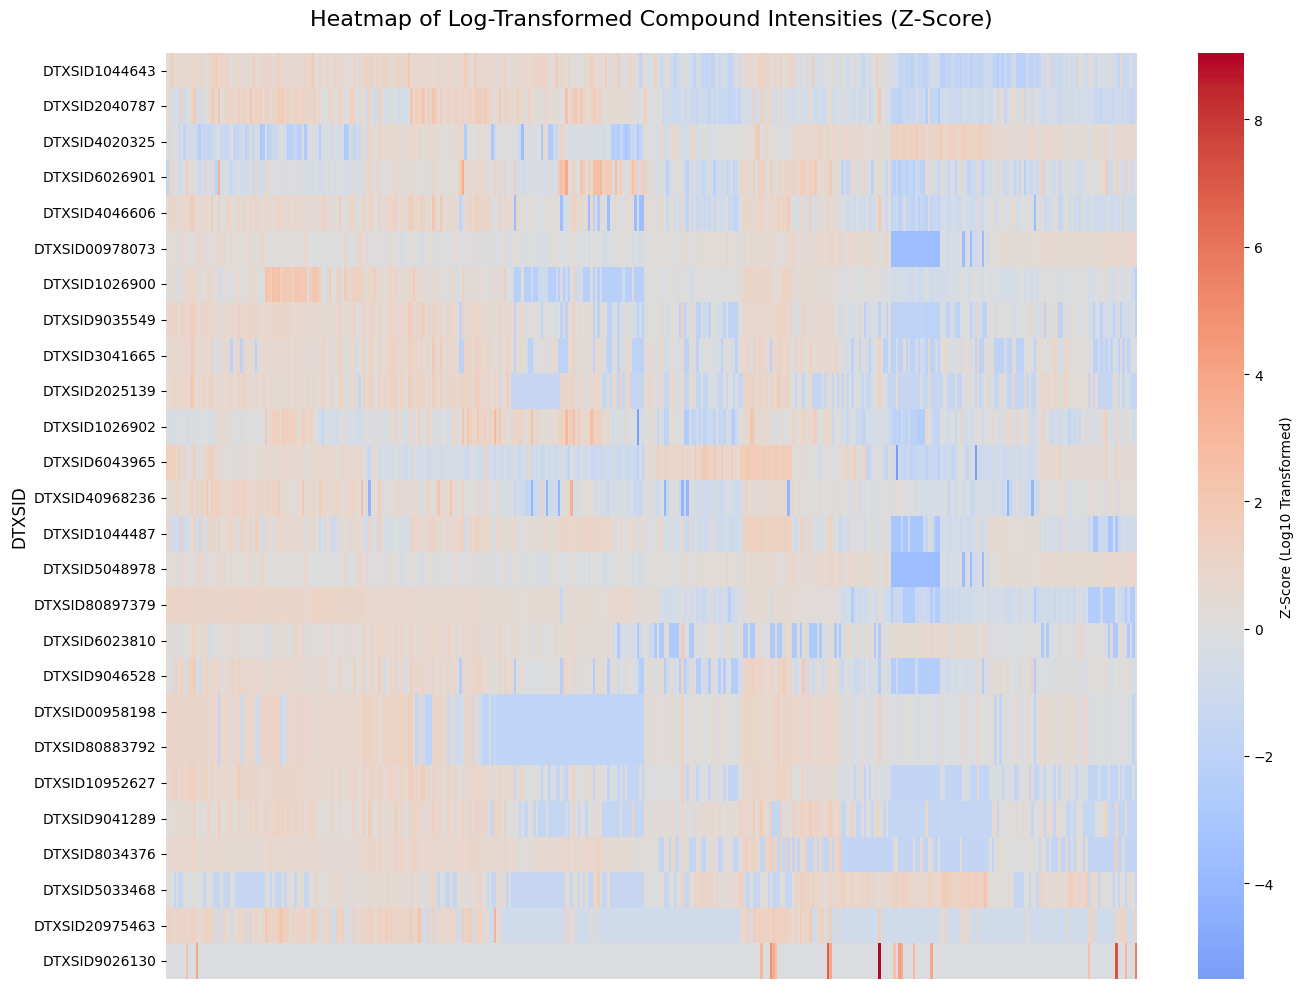

In [6]:
# 1. Add 1 to avoid log(0) errors, then apply log10 transformation
heatmap_log = np.log10(heatmap_df + 1)

# 2. Calculate Z-score on the LOG-TRANSFORMED data
heatmap_zscore_norm = heatmap_log.sub(heatmap_log.mean(axis=1), axis=0).div(heatmap_log.std(axis=1), axis=0)

# 3. Plotting
plt.figure(figsize=(14, 10))
ax = sns.heatmap(heatmap_zscore_norm, 
                 cmap='coolwarm',       # A diverging colormap is best for z-scores
                 center=0,              # Force 0 to be the middle color
                 linewidths=0.0,        # Turn off gridlines if you have hundreds of samples
                 cbar_kws={'label': 'Z-Score (Log10 Transformed)'},
                 xticklabels=False,     # Ignored x-axis labels as requested
                 yticklabels=True)

plt.title('Heatmap of Log-Transformed Compound Intensities (Z-Score)', fontsize=16, pad=20)
plt.ylabel('DTXSID', fontsize=12)
plt.tight_layout()
plt.show()

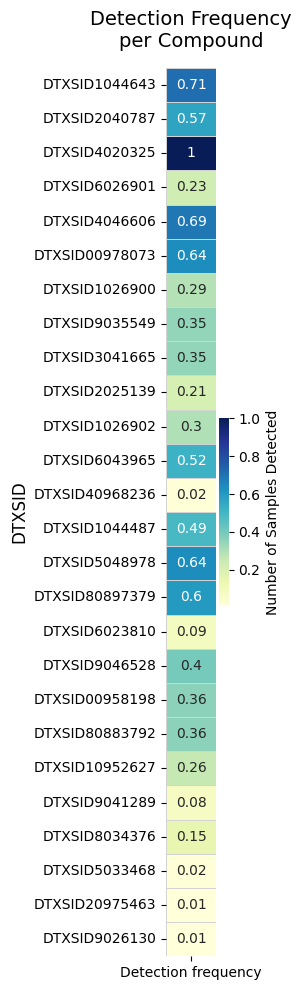

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the DTXSID and Detection_Freq columns
freq_df = selected_rows_df[['DTXSID', 'Detection frequency']].copy()
    #round detection frequency to two digit
freq_df['Detection frequency'] = freq_df['Detection frequency'].round(2)


# 2. Set DTXSID as the index for the y-axis labels
freq_df.set_index('DTXSID', inplace=True)

# 3. Plotting the 1D Heatmap
# We use a narrow width (e.g., 3) since there is only one column of data to display
plt.figure(figsize=(3, 10)) 

ax = sns.heatmap(freq_df, 
                 cmap='YlGnBu',         # Yellow to Green to Blue is excellent for count data
                 linewidths=0.5,        # Adds a slight grid to separate the rows cleanly
                 linecolor='lightgray',
                 annot=True,            # Set to True to print the actual count number inside the box
                 fmt='g',               # Formats the annotation as a standard integer
                 cbar_kws={'label': 'Number of Samples Detected'},
                 xticklabels=True,      # Will show "Detection_Freq" at the bottom
                 yticklabels=True)      # Shows the DTXSID labels

# 4. Formatting the plot
plt.title('Detection Frequency\nper Compound', fontsize=14, pad=15)
plt.xlabel('') # Leave blank, the column name handles this
plt.ylabel('DTXSID', fontsize=12)

# Ensure everything fits without getting cut off
plt.tight_layout()

# Save the plot
plt.savefig('DTXSID_Detection_Freq_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
############################################################ Molecular strucutre plot ###############################
# --- 1. Load the database ---
import pandas as pd
import tabulate
QA_database_path = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QACs_chemical_list_comptox_March09.csv'
peakmzrt = pd.read_csv(QA_database_path)
print(tabulate.tabulate(peakmzrt, headers='keys', tablefmt='psql'))

# --- 6. Reorder rows to put target DTXSIDs at the top ---
top_target = [
        'DTXSID4020325', # Added from your comment
        'DTXSID00978073',
        "DTXSID6026901",
        "DTXSID1026900",
        'DTXSID2040787',
        "DTXSID3041665",
        'DTXSID4046606',
        "DTXSID2025139" ]

#plot molecular structure using SMILES or InChiKey


+----+---------------------------------------------------------------+---------------------+--------------+--------+---------+-------------+------------+----------------+-------------------------------------------------------------------+-----------------+-------------+-----------------------------+---------------------------------------------------------------------+--------------------------+
|    | Name                                                          | MOLECULAR_FORMULA   |   Exact_mass |    RT1 |     RT2 | CASRN       | Synonyms   | DTXSID         | IUPACname                                                         | DTXCID          | CASRN.1     | PREFERRED_NAME              | SMILES                                                              |   MONOISOTOPIC_MASS_mass |
|----+---------------------------------------------------------------+---------------------+--------------+--------+---------+-------------+------------+----------------+----------------------------------

In [ ]:
#calibration curve data and do estimation
##reextract the peak area of internal standards for each sample,
##normalize each peak area by internal standards
##estimate the concentration by calibration curve
